# GRU + 2D CNN Fusion — Georgia ECG Dataset

Late-fusion of 1D GRU branch (raw ECG) + 2D CNN branch (STFT spectrogram) with CBAM attention.

In [1]:
import warnings; warnings.filterwarnings("ignore")
import numpy as np, pickle, pathlib, time
import torch, torch.nn as nn
import scipy.signal
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import f1_score, roc_auc_score, multilabel_confusion_matrix
from iterstrat.ml_stratifiers import MultilabelStratifiedShuffleSplit
import matplotlib.pyplot as plt
from PIL import Image

SEED=42; torch.manual_seed(SEED); np.random.seed(SEED)
DEVICE=torch.device("cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu")
print("Device:", DEVICE)

DATA_DIR=pathlib.Path("../../GeorgiaECG"); CKPT_DIR=pathlib.Path("checkpoints"); CKPT_DIR.mkdir(exist_ok=True)
NORM_CAP=4000; BATCH_SIZE=64; LR=3e-4; WEIGHT_DECAY=1e-4
MAX_EPOCHS=50; PATIENCE=15; WARMUP=5; NUM_CLASSES=4
CLASS_NAMES=["MI","STTC","CD","HYP"]; IMG_SIZE=64; FS=100

Device: cuda


## Load Data & Split

In [2]:
with open(DATA_DIR/"X_georgia.pickle","rb") as f: X_all=pickle.load(f)
with open(DATA_DIR/"y_georgia.pickle","rb") as f: y_all=pickle.load(f)
print(f"X: {X_all.shape}, y: {y_all.shape}")

rng=np.random.default_rng(SEED)
norm_idx=np.where(y_all.sum(axis=1)==0)[0]; disease_idx=np.where(y_all.sum(axis=1)>0)[0]
if len(norm_idx)>NORM_CAP: norm_idx=rng.choice(norm_idx,NORM_CAP,replace=False)
keep_idx=np.concatenate([norm_idx,disease_idx]); rng.shuffle(keep_idx)
X_all,y_all=X_all[keep_idx],y_all[keep_idx]

strat_cols=np.concatenate([y_all,(y_all.sum(1)==0).astype(np.float32)[:,None]],axis=1)
msss1=MultilabelStratifiedShuffleSplit(n_splits=1,test_size=0.15,random_state=SEED)
tr_val_idx,te_idx=next(msss1.split(X_all,strat_cols))
msss2=MultilabelStratifiedShuffleSplit(n_splits=1,test_size=0.176,random_state=SEED)
tr_idx,val_idx=next(msss2.split(X_all[tr_val_idx],strat_cols[tr_val_idx]))
tr_idx=tr_val_idx[tr_idx]; val_idx=tr_val_idx[val_idx]
X_train,y_train=X_all[tr_idx],y_all[tr_idx]; X_val,y_val=X_all[val_idx],y_all[val_idx]; X_test,y_test=X_all[te_idx],y_all[te_idx]
print(f"Train {len(tr_idx)} | Val {len(val_idx)} | Test {len(te_idx)}")

X: (10344, 12, 1000), y: (10344, 4)
Train 7230 | Val 1559 | Test 1555


## Fusion Dataset

In [3]:
def ecg_to_spectrogram(signal, fs=FS, img_size=IMG_SIZE):
    specs=[]
    for ch in range(signal.shape[0]):
        _,_,Zxx=scipy.signal.stft(signal[ch],fs=fs,nperseg=64,noverlap=48)
        mag=np.log1p(np.abs(Zxx)).astype(np.float32)
        mag=(mag-mag.min())/(mag.max()-mag.min()+1e-8)
        img=np.array(Image.fromarray((mag*255).astype(np.uint8)).resize((img_size,img_size),Image.BILINEAR),dtype=np.float32)/255.0
        specs.append(img)
    return np.stack(specs,axis=0)

class ECGFusionDataset(Dataset):
    def __init__(self,X,y): self.X=X; self.y=torch.from_numpy(y).float()
    def __len__(self): return len(self.X)
    def __getitem__(self,i):
        x_raw=torch.from_numpy(self.X[i]).float()        # (12,1000)
        x_spec=torch.from_numpy(ecg_to_spectrogram(self.X[i])).float()  # (12,64,64)
        return x_raw,x_spec,self.y[i]

_kw=dict(batch_size=BATCH_SIZE,num_workers=0,pin_memory=True)
tr_loader=DataLoader(ECGFusionDataset(X_train,y_train),shuffle=True,**_kw)
val_loader=DataLoader(ECGFusionDataset(X_val,y_val),shuffle=False,**_kw)
te_loader=DataLoader(ECGFusionDataset(X_test,y_test),shuffle=False,**_kw)

## Model: GRU + 2D CNN with CBAM Fusion

In [4]:
class CBAM(nn.Module):
    def __init__(self, channels, reduction=16):
        super().__init__()
        self.ca_avg=nn.AdaptiveAvgPool2d(1); self.ca_max=nn.AdaptiveMaxPool2d(1)
        self.ca_fc=nn.Sequential(nn.Linear(channels,channels//reduction),nn.ReLU(),nn.Linear(channels//reduction,channels))
        self.sa_conv=nn.Conv2d(2,1,kernel_size=7,padding=3,bias=False)
    def forward(self,x):
        avg=self.ca_avg(x).flatten(1); mx=self.ca_max(x).flatten(1)
        ca=torch.sigmoid(self.ca_fc(avg)+self.ca_fc(mx)).unsqueeze(-1).unsqueeze(-1)
        x=x*ca
        sa=torch.sigmoid(self.sa_conv(torch.cat([x.mean(1,keepdim=True),x.max(1,keepdim=True)[0]],dim=1)))
        return x*sa

class GRU_2DCNN_Fusion(nn.Module):
    def __init__(self,n_classes=NUM_CLASSES,gru_hidden=128,cnn_ch=64):
        super().__init__()
        # GRU branch: raw signal (N,12,1000)
        self.gru_cnn=nn.Sequential(
            nn.Conv1d(12,64,7,padding=3),nn.BatchNorm1d(64),nn.ReLU(),nn.MaxPool1d(4),
            nn.Conv1d(64,128,5,padding=2),nn.BatchNorm1d(128),nn.ReLU(),nn.MaxPool1d(5))
        self.bigru=nn.GRU(128,gru_hidden,num_layers=2,bidirectional=True,batch_first=True,dropout=0.2)
        # CNN branch: spectrogram (N,12,64,64)
        def conv_block(ci,co,k=3,p=1):
            return nn.Sequential(nn.Conv2d(ci,co,k,padding=p),nn.BatchNorm2d(co),nn.ReLU(),nn.MaxPool2d(2))
        self.cnn=nn.Sequential(conv_block(12,cnn_ch),conv_block(cnn_ch,cnn_ch*2),conv_block(cnn_ch*2,cnn_ch*4))
        self.cbam=CBAM(cnn_ch*4)
        self.cnn_pool=nn.AdaptiveAvgPool2d(1)
        # Fusion MLP: gru_hidden*2 + cnn_ch*4 = 256+256=512
        self.fusion=nn.Sequential(
            nn.Dropout(0.3),nn.Linear(gru_hidden*2+cnn_ch*4,128),nn.ReLU(),nn.Dropout(0.2),nn.Linear(128,n_classes))

    def forward(self,x_raw,x_spec):
        g=self.gru_cnn(x_raw).permute(0,2,1)
        g,_=self.bigru(g); g=g.mean(dim=1)
        c=self.cnn_pool(self.cbam(self.cnn(x_spec))).flatten(1)
        return self.fusion(torch.cat([g,c],dim=1))

model=GRU_2DCNN_Fusion().to(DEVICE)
print(f"Parameters: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")

Parameters: 993,142


## Loss, Optimizer, Scheduler

In [5]:
class FocalLoss(nn.Module):
    def __init__(self,alpha=0.25,gamma=2.0,pos_weight=None):
        super().__init__(); self.alpha=alpha; self.gamma=gamma
        self.bce=nn.BCEWithLogitsLoss(pos_weight=pos_weight,reduction="none")
    def forward(self,logits,targets):
        bce=self.bce(logits,targets)
        p_t=torch.sigmoid(logits)*targets+(1-torch.sigmoid(logits))*(1-targets)
        return (self.alpha*(1-p_t)**self.gamma*bce).mean()

pos_w=torch.tensor([(y_all.shape[0]-y_all[:,i].sum())/(y_all[:,i].sum()+1e-6) for i in range(NUM_CLASSES)],dtype=torch.float32).to(DEVICE)
criterion=FocalLoss(alpha=0.25,gamma=2.0,pos_weight=pos_w)
optimizer=torch.optim.AdamW(model.parameters(),lr=LR,weight_decay=WEIGHT_DECAY)
scheduler=torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer,factor=0.5,patience=5)

## Training

In [6]:
def run_epoch(loader,mdl,crit,opt=None):
    training=opt is not None; mdl.train() if training else mdl.eval()
    total_loss,all_probs,all_tgts=0.,[],[]
    ctx=torch.enable_grad() if training else torch.no_grad()
    with ctx:
        for x_raw,x_spec,yb in loader:
            x_raw,x_spec,yb=x_raw.to(DEVICE),x_spec.to(DEVICE),yb.to(DEVICE)
            logits=mdl(x_raw,x_spec); loss=crit(logits,yb)
            if training:
                opt.zero_grad(); loss.backward()
                nn.utils.clip_grad_norm_(mdl.parameters(),1.0); opt.step()
            total_loss+=loss.item()*len(yb)
            all_probs.append(torch.sigmoid(logits).detach().cpu().numpy())
            all_tgts.append(yb.detach().cpu().numpy())
    return total_loss/len(loader.dataset),np.concatenate(all_probs),np.concatenate(all_tgts)

In [7]:
train_losses,val_losses,val_f1s=[],[],[]
best_val_f1,best_state,best_ep,no_improve=0.,None,0,0

for epoch in range(1,MAX_EPOCHS+1):
    t0=time.time()
    tr_loss,_,_=run_epoch(tr_loader,model,criterion,optimizer)
    val_loss,val_probs,val_tgts=run_epoch(val_loader,model,criterion)
    val_f1=f1_score(val_tgts,(val_probs>=0.5).astype(int),average="macro",zero_division=0)
    scheduler.step(val_loss)
    train_losses.append(tr_loss); val_losses.append(val_loss); val_f1s.append(val_f1)
    marker=""
    if epoch>WARMUP and val_f1>best_val_f1:
        best_val_f1=val_f1; best_state={k:v.cpu().clone() for k,v in model.state_dict().items()}
        best_ep=epoch; no_improve=0; marker=" ✓"
    elif epoch>WARMUP: no_improve+=1
    print(f"Ep {epoch:3d} | tr {tr_loss:.4f} | val {val_loss:.4f} | F1 {val_f1:.4f} | {time.time()-t0:.1f}s{marker}")
    if epoch>WARMUP and no_improve>=PATIENCE: print("Early stopping."); break

torch.save(best_state,CKPT_DIR/"best_model.pt")
print(f"Best epoch {best_ep}, val F1 {best_val_f1:.4f}")

Ep   1 | tr 0.0570 | val 0.0523 | F1 0.5145 | 22.8s
Ep   2 | tr 0.0508 | val 0.0498 | F1 0.5556 | 22.5s
Ep   3 | tr 0.0486 | val 0.0494 | F1 0.5541 | 22.6s
Ep   4 | tr 0.0468 | val 0.0483 | F1 0.5879 | 22.6s
Ep   5 | tr 0.0454 | val 0.0497 | F1 0.5663 | 22.3s
Ep   6 | tr 0.0441 | val 0.0514 | F1 0.6042 | 22.4s ✓
Ep   7 | tr 0.0430 | val 0.0474 | F1 0.5956 | 24.2s
Ep   8 | tr 0.0421 | val 0.0470 | F1 0.5938 | 24.3s
Ep   9 | tr 0.0410 | val 0.0560 | F1 0.5960 | 24.3s
Ep  10 | tr 0.0406 | val 0.0483 | F1 0.6000 | 24.3s
Ep  11 | tr 0.0399 | val 0.0485 | F1 0.5749 | 24.3s
Ep  12 | tr 0.0389 | val 0.0491 | F1 0.6135 | 24.2s ✓
Ep  13 | tr 0.0376 | val 0.0512 | F1 0.5948 | 22.5s
Ep  14 | tr 0.0381 | val 0.0526 | F1 0.6109 | 22.5s
Ep  15 | tr 0.0349 | val 0.0487 | F1 0.6037 | 22.4s
Ep  16 | tr 0.0344 | val 0.0558 | F1 0.6170 | 22.3s ✓
Ep  17 | tr 0.0332 | val 0.0587 | F1 0.6196 | 22.2s ✓
Ep  18 | tr 0.0321 | val 0.0671 | F1 0.6139 | 22.4s
Ep  19 | tr 0.0314 | val 0.0810 | F1 0.6029 | 22.5s
Ep  

## Training Curves

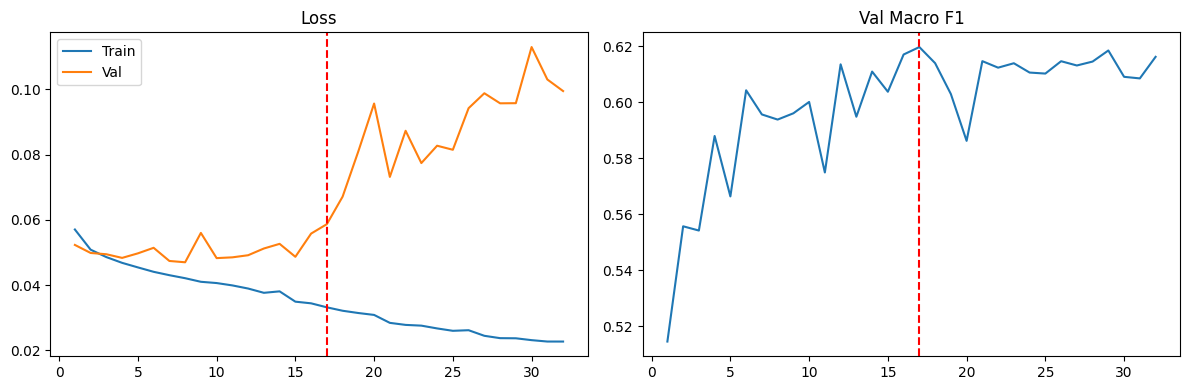

In [8]:
fig,(ax1,ax2)=plt.subplots(1,2,figsize=(12,4))
eps=range(1,len(train_losses)+1)
ax1.plot(eps,train_losses,label="Train"); ax1.plot(eps,val_losses,label="Val")
ax1.axvline(best_ep,color="r",ls="--"); ax1.legend(); ax1.set_title("Loss")
ax2.plot(eps,val_f1s); ax2.axvline(best_ep,color="r",ls="--"); ax2.set_title("Val Macro F1")
plt.tight_layout(); plt.savefig(CKPT_DIR/"training_curves.png",dpi=100); plt.show()

## Test Evaluation

In [9]:
model.load_state_dict(best_state); model_trained=model
_,val_probs_tune,val_tgts_tune=run_epoch(val_loader,model_trained,criterion)
_,test_probs,test_tgts=run_epoch(te_loader,model_trained,criterion)
cv_test_probs=val_probs_tune; cv_test_targets=val_tgts_tune

## Threshold Tuning (Val Set)

In [10]:
best_thresholds=[]
for i,name in enumerate(CLASS_NAMES):
    best_t,best_f=0.5,0.
    for t in np.arange(0.1,0.9,0.02):
        f=f1_score(cv_test_targets[:,i],(cv_test_probs[:,i]>=t).astype(int),zero_division=0)
        if f>best_f: best_f=f; best_t=t
    best_thresholds.append(best_t); print(f"  {name}: thresh={best_t:.2f} val_F1={best_f:.4f}")
tuned_arr=np.array(best_thresholds)

  MI: thresh=0.66 val_F1=0.4396
  STTC: thresh=0.50 val_F1=0.6935
  CD: thresh=0.42 val_F1=0.7286
  HYP: thresh=0.50 val_F1=0.6511


In [11]:
preds_def=(test_probs>=0.5).astype(int); preds_tuned=(test_probs>=tuned_arr).astype(int)
print(f"{'Class':<8} {'F1_def':>8} {'F1_tuned':>10}")
for i,name in enumerate(CLASS_NAMES):
    print(f"{name:<8} {f1_score(test_tgts[:,i],preds_def[:,i],zero_division=0):8.4f} {f1_score(test_tgts[:,i],preds_tuned[:,i],zero_division=0):10.4f}")
f1d=f1_score(test_tgts,preds_def,average="macro",zero_division=0)
f1t=f1_score(test_tgts,preds_tuned,average="macro",zero_division=0)
print(f"{'Macro':<8} {f1d:8.4f} {f1t:10.4f}")
try: print(f"AUC: {roc_auc_score(test_tgts,test_probs,average='macro'):.4f}")
except: pass

Class      F1_def   F1_tuned
MI         0.5041     0.5169
STTC       0.7079     0.7079
CD         0.7475     0.7418
HYP        0.6373     0.6373
Macro      0.6492     0.6510
AUC: 0.8458


## Confusion Matrices

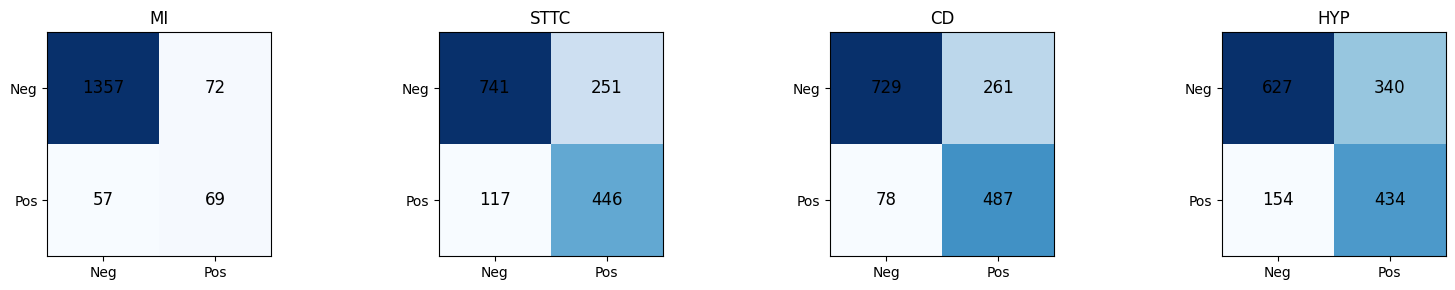

In [12]:
mcm=multilabel_confusion_matrix(test_tgts.astype(int),preds_tuned)
fig,axes=plt.subplots(1,4,figsize=(16,3))
for i,(ax,name) in enumerate(zip(axes,CLASS_NAMES)):
    ax.imshow(mcm[i],cmap="Blues"); ax.set_title(name)
    ax.set_xticks([0,1]); ax.set_yticks([0,1])
    ax.set_xticklabels(["Neg","Pos"]); ax.set_yticklabels(["Neg","Pos"])
    for r in range(2):
        for c in range(2): ax.text(c,r,mcm[i][r,c],ha="center",va="center",fontsize=12)
plt.tight_layout(); plt.savefig(CKPT_DIR/"confusion_matrices.png",dpi=100); plt.show()